In [ ]:
!pip install koreanize-matplotlib
!pip install shap
#!pip install -U sympy
import openpyxl
import pickle
import pandas as pd
import collections
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 애드온 설치
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 83.8 MB/s eta 0:00:00


In [ ]:
import datetime
import openpyxl
import pickle
import pandas as pd
import collections
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#!pip install neuralforecast
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler # 변경됨
import joblib # 스케일러 저장용

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from tqdm.auto import tqdm # Colab에서 진행률 보기 좋은 라이브러리
import torch
import torch.nn as nn
import torch.nn.functional as F
import datetime

In [ ]:
path = '/content/drive/MyDrive/범준학습/빅데이터/개인 발전량 예측 프로젝트(25)/Core/fromdb2_weighted.csv'
df_raw = pd.read_csv(path, encoding='cp949')

In [ ]:
# ==========================================
# 1. 하이퍼파라미터 및 기본 설정(풍력)
# ==========================================
SEQ_LEN = 72 #336
PRED_LEN = 24
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 1e-3

# [Transformer Backbone 파라미터]
PATCH_LEN = 12      # 패치 길이 (P)
STRIDE = 6       # 스트라이드 (S) - 겹치지 않게 이동 (Non-overlapping) 24 = non-overlap
EMBED_DIM = 4       # 범주형 변수 임베딩 (기존 유지)
D_MODEL = 128      # 트랜스포머 내부 차원 (Latent Dimension) / 기존 128
NUM_HEADS = 4       # 멀티헤드 어텐션 개수  /  기존에는 4였음
NUM_LAYERS = 2      # 인코더 레이어 깊이 (보통 3~6 정도) / 기존 3이였음
D_FF = 256         # FeedForward Layer 차원 (보통 D_MODEL * 2 or 4) / 기존 256
DROPOUT = 0.3     # 일반화 성능을 위해 드롭아웃 약간 상향 /  기존 0.3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# ==========================================
# 3. Dataset 수정 (past_y 추가)
# ==========================================
class PatchTSTDataset(Dataset):
    def __init__(self, data_array, seq_len, pred_len, future_idx, target_idx):
        self.data = data_array
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.future_idx = future_idx # 날씨/시간 피처들
        self.target_idx = target_idx # Solar_Utilization

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        # 과거 구간
        past_data = self.data[idx : idx + self.seq_len]ㅃ
        past_numeric = past_data[:, self.future_idx] # (SEQ_LEN, 16)
        past_y = past_data[:, self.target_idx : self.target_idx+1] # (SEQ_LEN, 1)

        # 미래 구간 (예보 정보)
        future_data = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        future_numeric = future_data[:, self.future_idx] # (PRED_LEN, 16)
        future_y = future_data[:, self.target_idx] # (PRED_LEN,)

        return {
            'past_numeric': torch.FloatTensor(past_numeric),
            'past_y': torch.FloatTensor(past_y),
            'future_numeric': torch.FloatTensor(future_numeric),
            'future_y': torch.FloatTensor(future_y)
        }

In [ ]:

class InstanceNormalization(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm', mean=None, std=None):
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            return (x - self.mean) / self.std * self.affine + self.bias
        elif mode == 'denorm':
            return (x - self.bias) / self.affine * std + mean
        return x

class Patch_Weather_Attention(nn.Module):
    def __init__(self, query_dim, key_dim, hidden_dim):
        super().__init__()
        self.W_Q = nn.Sequential(nn.Linear(query_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim))
        self.W_K = nn.Sequential(nn.Linear(key_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim))
        self.scale_factor = 1.0 / (hidden_dim ** 0.5)

    def forward(self, future_weather_patch, past_weather_patches, transformer_output):
        Q = self.W_Q(future_weather_patch).unsqueeze(1)
        K = self.W_K(past_weather_patches)
        score = torch.bmm(Q, K.transpose(1, 2)) * self.scale_factor
        attn_weights = F.softmax(score, dim=-1)
        context = torch.bmm(attn_weights, transformer_output)
        return context.squeeze(1), attn_weights

# ==========================================
# Weather Attetion Model
# ==========================================

class Patch_Weather_Attention(nn.Module):
    """
    통합 Weather Attention (query_dim / key_dim 분리)
    Solar: patch_len=24, pred_len=24 → query_dim == key_dim
    """
    def __init__(self, query_dim, key_dim, hidden_dim):
        super().__init__()
        self.W_Q = nn.Sequential(nn.Linear(query_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim))
        self.W_K = nn.Sequential(nn.Linear(key_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim))
        self.scale_factor = 1.0 / (hidden_dim ** 0.5)

    def forward(self, future_weather_patch, past_weather_patches, transformer_output):
        Q = self.W_Q(future_weather_patch).unsqueeze(1)
        K = self.W_K(past_weather_patches)
        score = torch.bmm(Q, K.transpose(1, 2)) * self.scale_factor
        attn_weights = F.softmax(score, dim=-1)
        context = torch.bmm(attn_weights, transformer_output)
        return context.squeeze(1), attn_weights

class PatchTST_Weather_Model(nn.Module):
    def __init__(self, num_features,
                 seq_len=336, pred_len=24, patch_len=24,
                 stride=12,
                 d_model=128,
                 num_heads=4,
                 num_layers=2,
                 d_ff=256, dropout=0.2):
        super(PatchTST_Weather_Model, self).__init__()

        self.patch_len = patch_len
        self.stride = stride
        self.d_model = d_model
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_patches = (self.seq_len - self.patch_len) // self.stride + 1


        #self.inst_norm = InstanceNormalization(num_features)

        patch_input_dim = self.patch_len * num_features
        self.patch_embedding = nn.Linear(patch_input_dim, self.d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, self.d_model))
        self.dropout = nn.Dropout(DROPOUT)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, nhead=NUM_HEADS, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)

        self.num_weather_feats = num_features - 1
        future_weather_flat_dim = self.pred_len * self.num_weather_feats
        weather_patch_dim = self.patch_len * self.num_weather_feats

        # 통합 Attention: Solar는 24*15 == 24*15 (동일)
        self.weather_attn = Patch_Weather_Attention(
            query_dim=future_weather_flat_dim,
            key_dim=weather_patch_dim,
            hidden_dim=self.d_model
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.d_model + future_weather_flat_dim, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(DROPOUT),
            nn.Linear(256, self.pred_len)
        )

        self.weather_bypass = nn.Linear(future_weather_flat_dim, self.pred_len) # Weather Byapass 추가

    def forward(self, batch):
        p_num = batch['past_numeric'].to(DEVICE)
        p_y = batch['past_y'].to(DEVICE)
        f_num = batch['future_numeric'].to(DEVICE)
        B = p_num.shape[0]

        x_past = torch.cat([p_num, p_y], dim=-1)
        #x_past = self.inst_norm(x_past, mode='norm')

        x_patches = x_past.unfold(dimension=1, size=self.patch_len, step=self.stride)
        x_patches = x_patches.permute(0, 1, 3, 2).reshape(B, self.num_patches, -1)

        enc_out = self.patch_embedding(x_patches) + self.pos_embedding
        enc_out = self.transformer_encoder(self.dropout(enc_out))

        future_weather_flat = f_num.reshape(B, -1)

        x_past_weather = x_past[..., :-1]
        w_patches = x_past_weather.unfold(1, self.patch_len, self.stride)
        w_patches = w_patches.permute(0, 1, 3, 2).reshape(B, self.num_patches, -1)

        context, _ = self.weather_attn(future_weather_flat, w_patches, enc_out)

        #total_input = torch.cat([context, future_weather_flat], dim=1) ## 기존방식
        #prediction = self.regressor(total_input)
        # 변경: future_weather 직접 shortcut

        total_input = torch.cat([context, future_weather_flat], dim=1)
        main_pred = self.regressor(total_input)
        weather_shortcut = self.weather_bypass(future_weather_flat)  # 간단한 Linear
        prediction = main_pred + weather_shortcut

        return prediction

In [ ]:
df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df = df.sort_index()

In [ ]:
df = df.drop(columns=['wd_sin', 'wd_cos', 'wind_spd'])
rename_map = {
    'wind_spd_north' : 'wind_spd',
    'wd_cos_north': 'wd_cos',
    'wd_sin_north': 'wd_sin'
}

# 2. 컬럼명 변경 적용
df = df.rename(columns=rename_map)
#df = df.drop(columns=['wd_sin_north', 'wd_cos_north', 'wind_spd_north'])
# 3. 결과 확인
print(df.columns)

Index(['supply_cap', 'real_demand', 'real_renew_gen', 'real_solar_gen',
       'real_wind_gen', 'smp_jeju', 'smp_land', 'est_demand', 'temp_c',
       'rainfall', 'humidity', 'solar_rad', 'total_cloud', 'midlow_cloud',
       'wind_spd', 'wd_sin', 'wd_cos', 'Solar_Capacity_Est',
       'Wind_Capacity_Est', 'Solar_Utilization', 'Wind_Utilization',
       'HVDC_Total', 'LNG_Gen', 'Oil_Gen', 'updated_at'],
      dtype='object')


In [ ]:
# 시간 파생 변수 생성
df['Hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['Year_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['Year_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

In [ ]:
print(f"df 전체 행 수: {len(df)}")
print(f"df.loc['2020-01-01':'2024-09-30'] 행 수: {len(df.loc['2020-01-01':'2024-09-30'])}")
print(f"Wind_Utilization 결측: {df['Wind_Utilization'].isna().sum()}")

df 전체 행 수: 54600
df.loc['2020-01-01':'2024-09-30'] 행 수: 41640
Wind_Utilization 결측: 5


In [ ]:
df['raw_spd'] = df['wind_spd']

WIND_SPD_CAP = 20.0
CUTOFF_WIND_SPD = 25.0

conditions = [
    df['wind_spd'] < 15,                                    # 정상 출력 증가
    (df['wind_spd'] >= 15) & (df['wind_spd'] < 20),         # rated power
    (df['wind_spd'] >= 20) & (df['wind_spd'] < CUTOFF_WIND_SPD),  # 과도기
    df['wind_spd'] >= CUTOFF_WIND_SPD                        # cut-off
]
values = [0.0, 1.0, 0.5, 0.0]
df['wind_zone'] = np.select(conditions, values, default=0.0)

df = df.copy()
df['wind_spd'] = df['wind_spd'].clip(upper=WIND_SPD_CAP)
df['wind_spd_sq'] = df['wind_spd'] ** 2
df['wind_spd_cu'] = df['wind_spd'] ** 3

df.loc[df['raw_spd'] >= CUTOFF_WIND_SPD, 'Wind_Utilization'] = 0.0


In [ ]:
# 임시보간
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].interpolate(limit=3)

In [ ]:
# ==========================================
# 풍력(Wind) 예측을 위한 PatchTST 모델 학습
# ==========================================

# 기존 테스트 기준
#train_df_wind = df.loc['2020-01-01':'2024-09-30'].copy()
#val_df_wind   = df.loc['2024-10-01':'2025-09-30'].copy()
#test_df_wind  = df.loc['2025-10-01':].copy()
# Pre-training: 구 설비 (기본 풍속-이용률 패턴 학습)

train_df_wind = df.loc['2020-01-01':'2025-06-30'].copy()
val_df_wind   = df.loc['2025-07-01':'2026-03-13'].copy()  # 여름+가을+겨울 약 8개월


# 20m/s 이상은 이것저것 데이터가 오염됨, 일단은 제거 후 후처리
train_df_wind = train_df_wind[train_df_wind['raw_spd'] <= WIND_SPD_CAP].copy()
val_df_wind = val_df_wind[val_df_wind['raw_spd'] <= WIND_SPD_CAP].copy()

# 1. 타겟 및 피처 재설정
features_wind = [
    'wind_spd', 'wind_spd_sq', 'wind_spd_cu', 'wd_sin', 'wd_cos',
    'Hour_sin', 'Hour_cos', 'Year_sin', 'Year_cos', 'wind_zone',
    'Wind_Utilization'
]
future_features_wind = [col for col in features_wind if 'Utilization' not in col]

# 2. 스케일러 적용 (한 번에 fit_transform 사용)
scaler_wind = MinMaxScaler()

# 💡 fit()과 transform()을 합친 fit_transform()을 사용하면 코드가 더 깔끔해집니다.
train_df_wind[future_features_wind] = scaler_wind.fit_transform(train_df_wind[future_features_wind])
val_df_wind[future_features_wind] = scaler_wind.transform(val_df_wind[future_features_wind])
#test_df_wind[future_features_wind] = scaler_wind.transform(test_df_wind[future_features_wind])

future_cov_idx_wind = [features_wind.index(col) for col in future_features_wind]
target_idx_wind = features_wind.index('Wind_Utilization')


# 2. 모델 및 학습 도구 초기화
input_size_wind = len(future_features_wind) + 1  # future_features + target
model_wind = PatchTST_Weather_Model(
    num_features=input_size_wind,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)

optimizer_wind = torch.optim.AdamW(model_wind.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# 풍력은 24시간 발전하므로 MSE 또는 MAE 선택 가능
# MSE: 큰 오차에 더 민감 (이상치 페널티 강함)
# MAE: 전반적 오차에 균등하게 민감
criterion_wind = nn.MSELoss()
#criterion_wind = nn.L1Loss()
#criterion_wind = nn.HuberLoss(delta=0.05)

scheduler_wind = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_wind, mode='min', factor=0.5, patience=5
)

# 3. Dataset 및 Loader 생성
train_ds_wind = PatchTSTDataset(
    train_df_wind[features_wind].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx_wind,  # Wind용 future covariate 인덱스
    target_idx_wind        # Wind_Utilization 인덱스
)
train_loader_wind = DataLoader(
    train_ds_wind,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_ds_wind = PatchTSTDataset(
    val_df_wind[features_wind].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx_wind,
    target_idx_wind
)
val_loader_wind = DataLoader(
    val_ds_wind,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 4. Training Loop
best_val_loss_wind = float('inf')
patience = 20
patience_counter = 0

print(f"✅ 풍력 전용 스케일러 중앙값 확인: {scaler_wind}") # 여기서 5.5 같은 숫자가 보이면 성공!)

✅ 풍력 전용 스케일러 중앙값 확인: MinMaxScaler()


/tmp/ipykernel_5715/2347305038.py:84: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)


In [ ]:
train_df_raw = df.loc['2020-01-01':'2024-09-30'].copy()
scaler_fresh = MinMaxScaler()
scaler_fresh.fit(train_df_raw[future_features_wind])

#print("Fresh scaler center:", scaler_fresh.center_[:5])
print("Fresh scaler scale:", scaler_fresh.scale_[:5])
print(df.loc['2026-03-16 00:00:00'][['temp_c', 'wind_spd', 'humidity']])

# ft_val_df에서 3월 16일 구간 직접 추출
target_start = '2026-03-02 00:00:00'  # 336시간 전
target_end = '2026-03-16 23:00:00'

sample_df = df.loc[target_start:target_end]
print("sample length:", len(sample_df))

past_numeric = torch.FloatTensor(sample_df.iloc[:336][future_features_wind].values).unsqueeze(0)
past_y = torch.FloatTensor(sample_df.iloc[:336][['Wind_Utilization']].values).unsqueeze(0)
future_numeric = torch.FloatTensor(sample_df.iloc[336:360][future_features_wind].values).unsqueeze(0)

print("=== Colab 3/16 Debug ===")
print("past_numeric mean:", past_numeric.mean().item())
print("past_numeric std:", past_numeric.std().item())
print("past_y mean:", past_y.mean().item())
print("future_numeric mean:", future_numeric.mean().item())
print("past_numeric[0,0,:5]:", past_numeric[0, 0, :5].tolist())
print("future_numeric[0,0,:5]:", future_numeric[0, 0, :5].tolist())
# Colab
print("Colab features:", future_features_wind)
#print("Colab scaler center:", scaler_wind.center_[:5])
print("Colab scaler scale:", scaler_wind.scale_[:5])

Fresh scaler scale: [5.00e-02 2.50e-03 1.25e-04 5.00e-01 5.00e-01]
temp_c       8.4
wind_spd     6.6
humidity    63.0
Name: 2026-03-16 00:00:00, dtype: object
sample length: 360
=== Colab 3/16 Debug ===
past_numeric mean: 18.035903930664062
past_numeric std: 81.05870056152344
past_y mean: 0.3109070360660553
future_numeric mean: 7.247594833374023
past_numeric[0,0,:5]: [4.289999961853027, 18.40410041809082, 78.9535903930664, 0.8859999775886536, 0.46369999647140503]
future_numeric[0,0,:5]: [6.599999904632568, 43.560001373291016, 287.4960021972656, -0.7833999991416931, 0.6215000152587891]
Colab features: ['wind_spd', 'wind_spd_sq', 'wind_spd_cu', 'wd_sin', 'wd_cos', 'Hour_sin', 'Hour_cos', 'Year_sin', 'Year_cos', 'wind_zone']
Colab scaler scale: [5.56792873e-02 3.10018303e-03 1.72615982e-04 5.00000000e-01
 5.00000000e-01]


In [ ]:
df[features_wind].describe()

,wind_spd,wind_spd_sq,wind_spd_cu,wd_sin,wd_cos,Hour_sin,Hour_cos,Year_sin,Year_cos,wind_zone,Wind_Utilization
count,54598.000000,54598.000000,54598.000000,54598.000000,54598.000000,5.460000e+04,5.460000e+04,54600.000000,54600.000000,54600.000000,54598.000000
mean,4.098381,23.259990,167.170447,0.032539,0.171606,-1.899986e-17,-5.553555e-17,0.022153,0.025967,0.001209,0.279374
std,2.542319,29.966046,359.417511,0.670192,0.721353,7.071133e-01,7.071133e-01,0.705341,0.708059,0.034482,0.258063
min,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000e+00,-0.999991,-0.999963,0.000000,0.000000
25%,2.180000,4.752400,10.360232,-0.575800,-0.558500,-7.071068e-01,-7.071068e-01,-0.687053,-0.683919,0.000000,0.062722
50%,3.640000,13.249600,48.228544,0.000000,0.399200,6.123234e-17,-6.123234e-17,0.051620,0.055917,0.000000,0.190873
75%,5.420000,29.376400,159.220088,0.693550,0.840000,7.071068e-01,7.071068e-01,0.723644,0.726608,0.000000,0.444751
max,20.000000,400.000000,8000.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,0.999991,1.000000,1.000000,1.000000


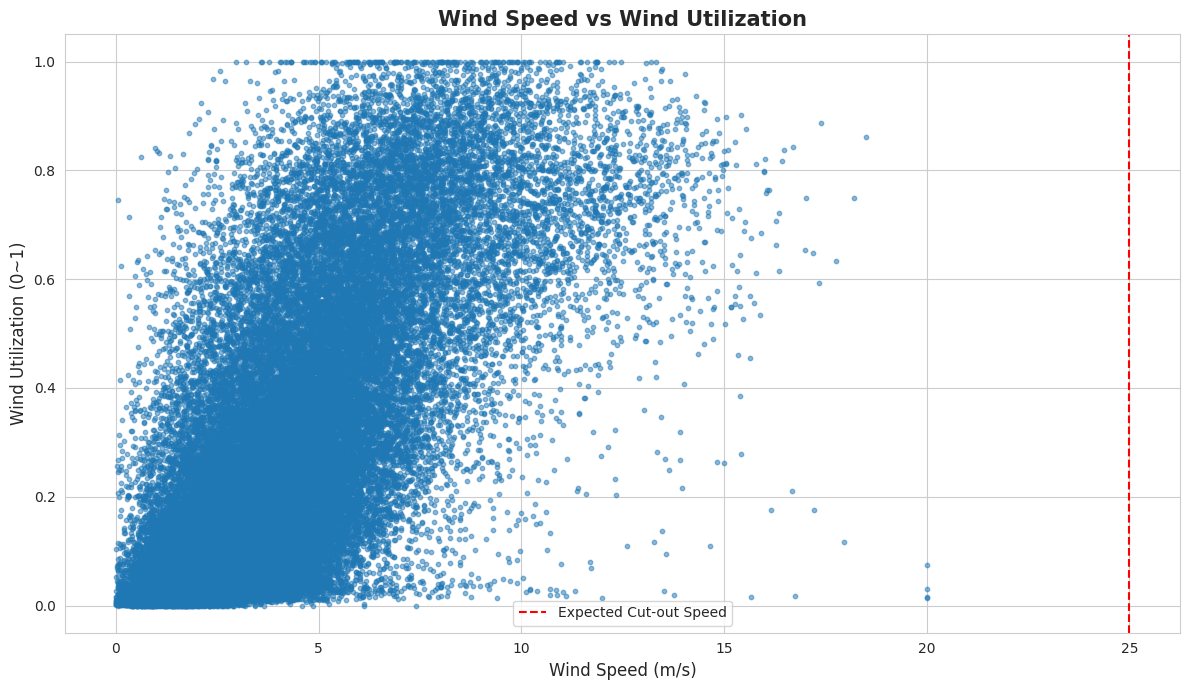

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

plt.scatter(
    x=df['wind_spd'],
    y=df['Wind_Utilization'],
    alpha=0.5,
    s=10,
    color='#1f77b4'
)

plt.axvline(x=25, color='red', linestyle='--', linewidth=1.5, label='Expected Cut-out Speed')

plt.title('Wind Speed vs Wind Utilization', fontsize=15, fontweight='bold')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Wind Utilization (0~1)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"train 데이터 행 수: {len(train_df_wind[features_wind].values)}")
print(f"필요 최소: {SEQ_LEN + PRED_LEN} = {SEQ_LEN} + {PRED_LEN}")
print(f"Dataset 길이: {len(train_df_wind[features_wind].values) - SEQ_LEN - PRED_LEN + 1}")
print(f"현재 SEQ_LEN: {SEQ_LEN}")

train 데이터 행 수: 48188
필요 최소: 96 = 72 + 24
Dataset 길이: 48093
현재 SEQ_LEN: 72


In [ ]:
print(f"🌬️ {DEVICE} 장치에서 풍력 예측 모델 학습을 시작합니다...")
print(f"📊 Input Features: {input_size_wind} (Future: {len(future_features_wind)}, Target: 1)")

for epoch in range(1, EPOCHS + 1):
    # --- [1] Training Phase ---
    model_wind.train()
    train_loss = 0.0

    # tqdm 진행바 설정
    train_pbar = tqdm(
        train_loader_wind,
        desc=f"Epoch {epoch}/{EPOCHS} [Wind Train]",
        leave=False
    )

    for batch in train_pbar:
        optimizer_wind.zero_grad()

        output = model_wind(batch)
        target = batch['future_y'].to(DEVICE)

        loss = criterion_wind(output, target)
        loss.backward()

        # Gradient Clipping (학습 안정성 확보)
        torch.nn.utils.clip_grad_norm_(model_wind.parameters(), max_norm=1.0)

        optimizer_wind.step()
        train_loss += loss.item()

        # 실시간 손실 업데이트
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader_wind)

    # --- [2] Validation Phase ---
    model_wind.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader_wind:
            output = model_wind(batch)
            target = batch['future_y'].to(DEVICE)

            loss = criterion_wind(output, target)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader_wind)

    # --- [3] Scheduler & Logging ---
    scheduler_wind.step(avg_val_loss)
    current_lr = optimizer_wind.param_groups[0]['lr']

    # Loss 지표명을 criterion에 따라 표시
    if isinstance(criterion_wind, nn.MSELoss):
        loss_metric = "MSE"
    elif isinstance(criterion_wind, nn.L1Loss):
        loss_metric = "MAE"
    elif isinstance(criterion_wind, nn.HuberLoss):
        loss_metric = "Huber"
    else:
        loss_metric = "Loss"

    print(f"Epoch [{epoch:03d}] | Train {loss_metric}: {avg_train_loss:.4f} | "
          f"Val {loss_metric}: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    # --- [4] Early Stopping & Model Save ---
    if avg_val_loss < best_val_loss_wind:
        best_val_loss_wind = avg_val_loss
        patience_counter = 0
        # 가장 좋은 모델 가중치 저장
        torch.save(model_wind.state_dict(), 'best_patchtst_wind_model_weighted.pth')
        print(f"✨ Best Wind Model Saved! (Val Loss: {best_val_loss_wind:.4f})")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"🛑 조기 종료! {patience} 에폭 동안 개선이 없었습니다.")
        break

print("-" * 50)
print(f"✅ 풍력 예측 모델 학습 완료!")
print(f"📈 최적 Validation {loss_metric}: {best_val_loss_wind:.4f}")
print(f"💾 모델 저장 경로: best_patchtst_wind_model_weighted.pth")
# 4. 저장 (이 파일을 Streamlit 폴더로 가져가세요!)
joblib.dump(scaler_wind, 'minmax_scaler_wind_weighted.pkl')
print("✅ 꽉 찬 풍력 전용 스케일러 저장 완료!")
#단순 minmax = 0.046
#weigthed_wind?
#기존 huber 0.049

🌬️ cuda 장치에서 풍력 예측 모델 학습을 시작합니다...
📊 Input Features: 11 (Future: 10, Target: 1)


Epoch 1/100 [Wind Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch [001] | Train MSE: 0.0313 | Val MSE: 0.0237 | LR: 0.001000
✨ Best Wind Model Saved! (Val Loss: 0.0237)


Epoch 2/100 [Wind Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch [002] | Train MSE: 0.0217 | Val MSE: 0.0218 | LR: 0.001000
✨ Best Wind Model Saved! (Val Loss: 0.0218)


...

Epoch [017] | Train MSE: 0.0137 | Val MSE: 0.0234 | LR: 0.000250


Epoch 18/100 [Wind Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch [018] | Train MSE: 0.0130 | Val MSE: 0.0224 | LR: 0.000250


Epoch 19/100 [Wind Train]:   0%|          | 0/375 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Colab에서 실행
joblib.dump(scaler_wind, 'robust_scaler_wind_ft.pkl')

['robust_scaler_wind_ft.pkl']

/tmp/ipykernel_5715/2347305038.py:84: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)


✅ /content/best_patchtst_wind_model_weighted.pth 로드 완료!
✅ Test Dataset: 1897개 샘플 (기간: 2026-01-01 00:00:00 ~ 2026-03-24 23:00:00)


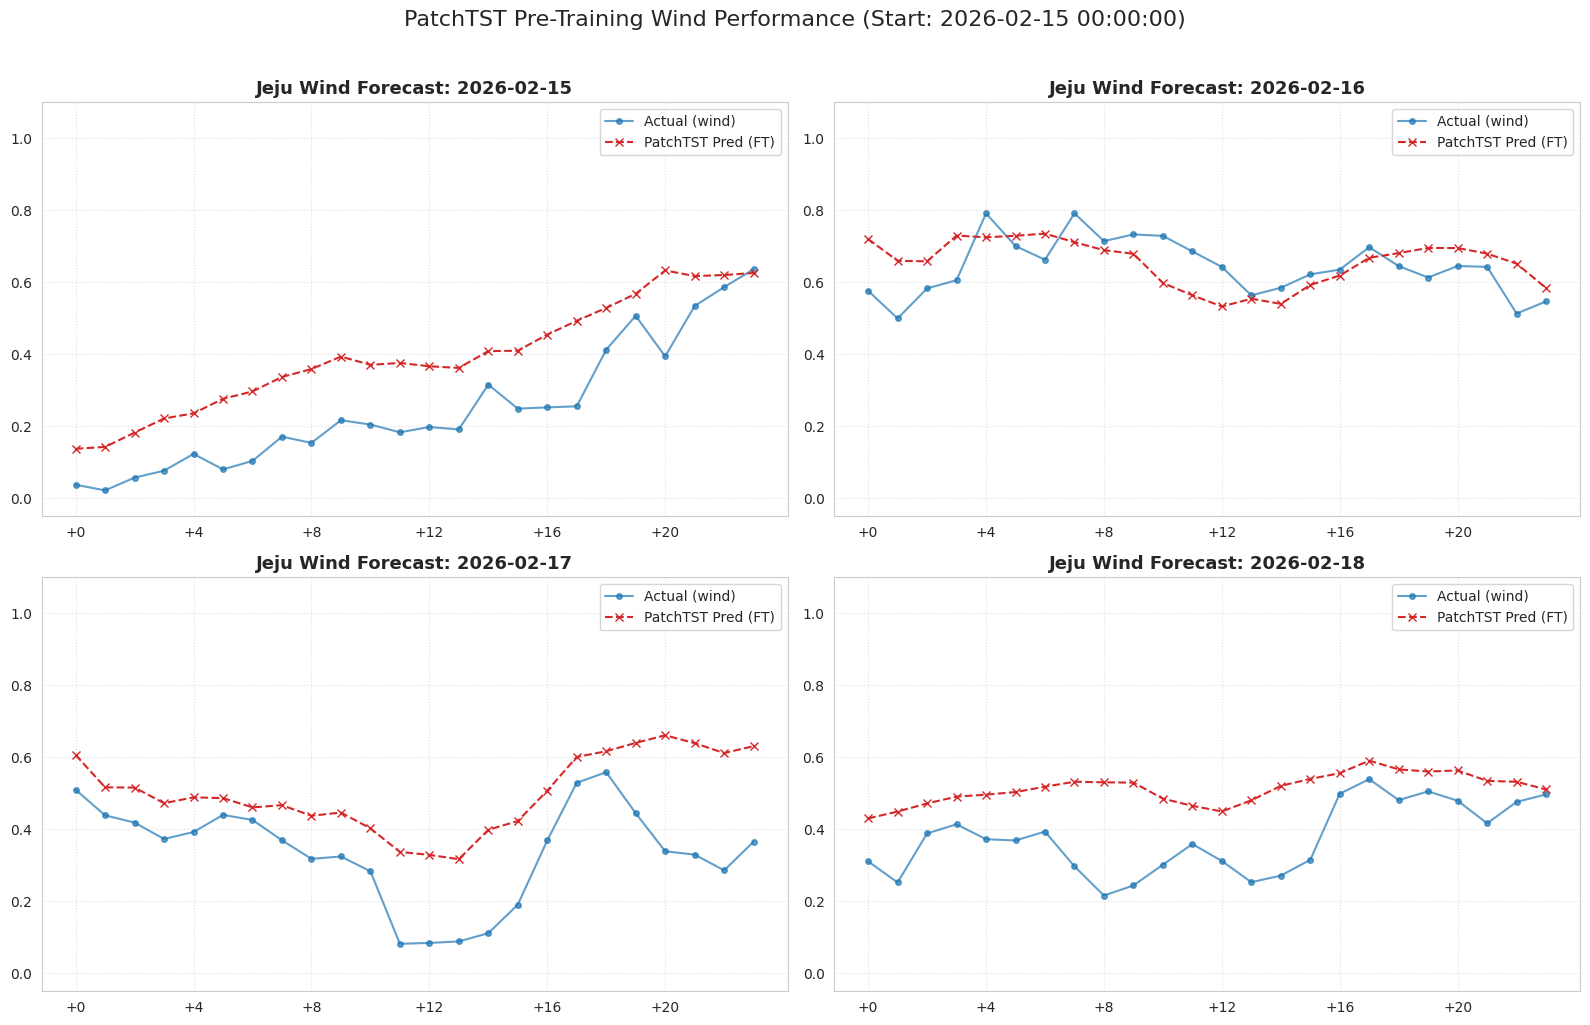

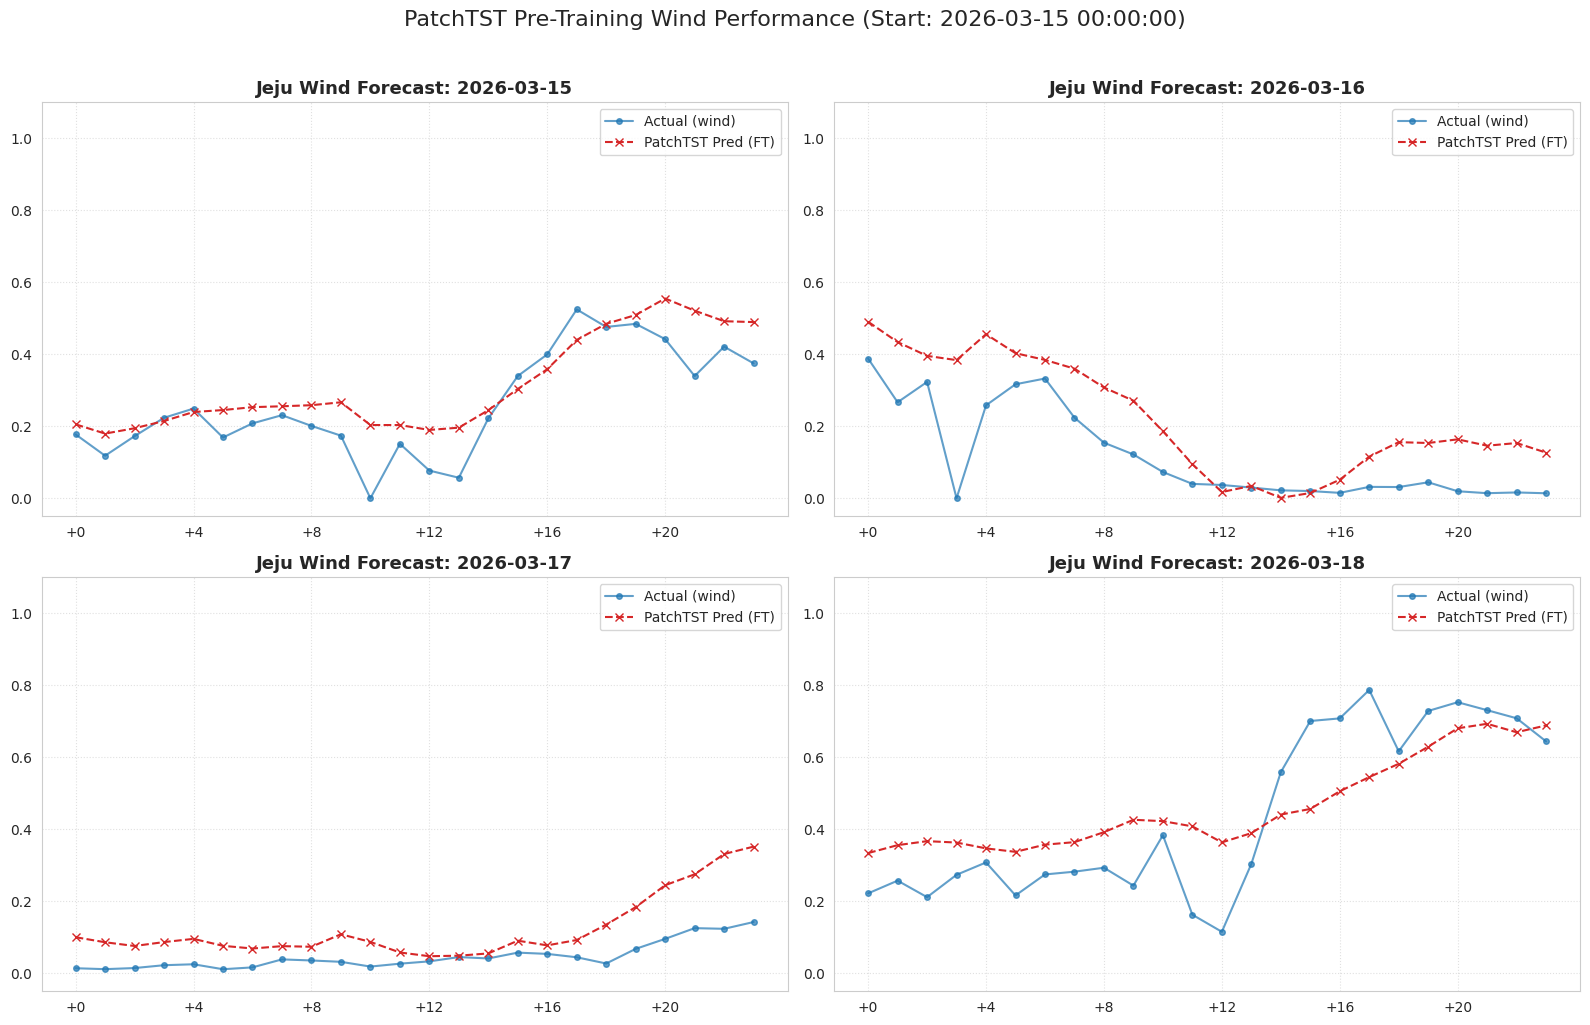

In [ ]:
# ==========================================
# Pretraining 모델 평가
# ==========================================

best_model = PatchTST_Weather_Model(
    num_features=input_size_wind,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)

#weights_path = '/content/models/best_patchtst_wind_model_ft.pth'
weights_path = '/content/best_patchtst_wind_model_weighted.pth'
best_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
best_model.eval()
print(f"✅ {weights_path} 로드 완료!")

# Test Dataset (26년 1월~ 데이터)
test_df_wind = df.loc['2026-01-01':].copy()
test_df_wind[future_features_wind] = scaler_wind.transform(test_df_wind[future_features_wind])

test_ds_wind = PatchTSTDataset(
    test_df_wind[features_wind].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx_wind,
    target_idx_wind
)
print(f"✅ Test Dataset: {len(test_ds_wind)}개 샘플 (기간: {test_df_wind.index[0]} ~ {test_df_wind.index[-1]})")

# ==========================================
# 시각화 함수
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

def plot_patchtst_forecast(start_date_str):
    try:
        target_start_loc = test_df_wind.index.get_loc(start_date_str)
    except KeyError:
        print(f"❌ '{start_date_str}'는 테스트 데이터 기간에 없습니다.")
        print(f"   사용 가능 기간: {test_df_wind.index[SEQ_LEN]} ~ {test_df_wind.index[-PRED_LEN]}")
        return

    base_idx = target_start_loc - SEQ_LEN
    if base_idx < 0 or base_idx + 72 >= len(test_ds_wind):
        print("❌ 시퀀스 데이터가 부족하여 그래프를 그릴 수 없습니다.")
        return

    indices = [base_idx, base_idx + 24, base_idx + 48, base_idx + 72]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = test_ds_wind[idx]
            batch_sample = {k: v.unsqueeze(0).to(DEVICE) for k, v in sample.items()}
            pred_y = best_model(batch_sample)

            actual = sample['future_y'].numpy()
            predicted = pred_y.squeeze().cpu().numpy()

            current_date = test_df_wind.index[target_start_loc + (i * 24)].strftime('%Y-%m-%d')

            ax = axes[i]
            ax.plot(actual, label='Actual (wind)', marker='o', markersize=4, color='#1f77b4', alpha=0.7)
            ax.plot(predicted, label='PatchTST Pred (FT)', marker='x', linestyle='--', color='#d62728', linewidth=1.5)
            ax.set_title(f"Jeju Wind Forecast: {current_date}", fontsize=13, fontweight='bold')
            ax.set_ylim(-0.05, 1.1)
            ax.set_xticks(range(0, 24, 4))
            ax.set_xticklabels([f"+{h}" for h in range(0, 24, 4)])
            ax.legend(loc='upper right')
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"PatchTST Pre-Training Wind Performance (Start: {start_date_str})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 실행
#plot_patchtst_forecast('2026-01-15 00:00:00')
plot_patchtst_forecast('2026-02-15 00:00:00')
plot_patchtst_forecast('2026-03-15 00:00:00')

Base MSE Loss: 0.0220
Feature: wind_spd        | Shuffled Loss: 0.0643 | Importance: 0.0423
Feature: wind_spd_sq     | Shuffled Loss: 0.0495 | Importance: 0.0274
Feature: wind_spd_cu     | Shuffled Loss: 0.0259 | Importance: 0.0039
Feature: wd_sin          | Shuffled Loss: 0.0285 | Importance: 0.0065
Feature: wd_cos          | Shuffled Loss: 0.0240 | Importance: 0.0019
Feature: Hour_sin        | Shuffled Loss: 0.0223 | Importance: 0.0003
Feature: Hour_cos        | Shuffled Loss: 0.0226 | Importance: 0.0006
Feature: Year_sin        | Shuffled Loss: 0.0223 | Importance: 0.0002
Feature: Year_cos        | Shuffled Loss: 0.0221 | Importance: 0.0001
Feature: wind_zone       | Shuffled Loss: 0.0355 | Importance: 0.0134


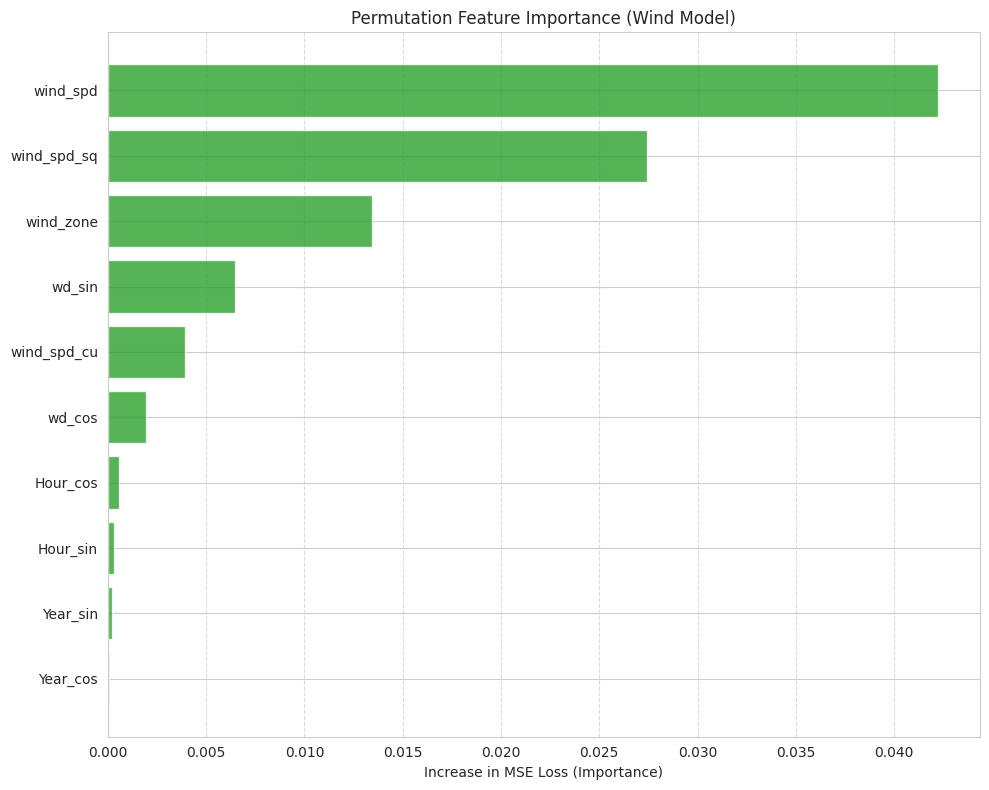

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def calculate_wind_permutation_importance(model, dataset, feature_names, device, batch_size=128):
    model.eval()
    criterion = nn.MSELoss()
    # 셔플을 하지 않아야 시계열 순서대로 안정적인 배치가 생성됩니다.
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # 1. 원본 데이터의 Base Loss 계산
    base_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch_to_device = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch_to_device)
            loss = criterion(pred, batch_to_device['future_y'])
            base_loss += loss.item() * batch['future_y'].size(0)
    base_loss /= len(dataset)
    print(f"Base MSE Loss: {base_loss:.4f}")

    importances = {}

    # 2. 피처별로 순서를 섞어가며 Loss 변화 측정
    for c_idx, col_name in enumerate(feature_names):
        shuffled_loss = 0.0
        with torch.no_grad():
            for batch in loader:
                # 데이터 원본 보존을 위해 복사본(clone) 생성
                p_num = batch['past_numeric'].clone()
                f_num = batch['future_numeric'].clone()

                # 배치 차원(Batch Dimension)을 기준으로 랜덤 인덱스 생성
                rand_idx = torch.randperm(p_num.size(0))

                # 해당 피처(c_idx)의 데이터만 랜덤하게 섞음 (노이즈화)
                p_num[:, :, c_idx] = p_num[rand_idx, :, c_idx]
                f_num[:, :, c_idx] = f_num[rand_idx, :, c_idx]

                shuffled_batch = {
                    'past_numeric': p_num.to(device),
                    'past_y': batch['past_y'].to(device),
                    'future_numeric': f_num.to(device),
                    'future_y': batch['future_y'].to(device)
                }

                pred = model(shuffled_batch)
                loss = criterion(pred, shuffled_batch['future_y'])
                shuffled_loss += loss.item() * p_num.size(0)

        shuffled_loss /= len(dataset)

        # 중요도 = 섞었을 때의 Loss - 원본 Loss
        importance_score = shuffled_loss - base_loss
        importances[col_name] = importance_score
        print(f"Feature: {col_name:<15} | Shuffled Loss: {shuffled_loss:.4f} | Importance: {importance_score:.4f}")

    # 3. 중요도 순으로 정렬 및 시각화
    sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=False)

    names = [item[0] for item in sorted_importances]
    scores = [item[1] for item in sorted_importances]

    plt.figure(figsize=(10, 8))
    # 풍력 데이터임을 직관적으로 알 수 있게 색상을 약간 다르게(청록색) 주었습니다.
    plt.barh(names, scores, color='#2ca02c', alpha=0.8)
    plt.xlabel('Increase in MSE Loss (Importance)')
    plt.title('Permutation Feature Importance (Wind Model)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return sorted_importances

# ==========================================
# 실행 부분
# ==========================================
# future_features_wind는 테스트 데이터셋에 입력된 피처 리스트(예: ['wind_spd', 'is_cutoff', ...])여야 합니다.
wind_imp_results = calculate_wind_permutation_importance(
    model=best_model,
    dataset=test_ds_wind,
    feature_names=future_features_wind,
    device=DEVICE,
    batch_size=BATCH_SIZE
)

In [ ]:
# ==========================================
# Wind Fine-tuning (24년 12월 이후 데이터)
# ==========================================

model_wind.load_state_dict(torch.load('/content/best_patchtst_wind_model_minmax.pth', map_location=DEVICE))

# 2. 낮은 learning rate (기존의 1/10)
optimizer_ft = torch.optim.AdamW(model_wind.parameters(), lr=1e-4, weight_decay=1e-5)
criterion_wind = nn.HuberLoss(delta=0.05)

# Fine-tuning: 신 설비 (북서풍 시즌 포함)
ft_train_df = df.loc['2024-12-01':'2025-09-30'].copy()  # 겨울+봄+여름
ft_val_df   = df.loc['2025-10-01':'2026-03-13'].copy()  # 가을+겨울

ft_train_df = ft_train_df[ft_train_df['raw_spd'] <= WIND_SPD_CAP].copy()
ft_val_df   = ft_val_df[ft_val_df['raw_spd'] <= WIND_SPD_CAP].copy()

ft_train_df[future_features_wind] = scaler_wind.transform(ft_train_df[future_features_wind])
ft_val_df[future_features_wind] = scaler_wind.transform(ft_val_df[future_features_wind])

ft_train_ds = PatchTSTDataset(ft_train_df[features_wind].values, SEQ_LEN, PRED_LEN, future_cov_idx_wind, target_idx_wind)
ft_val_ds = PatchTSTDataset(ft_val_df[features_wind].values, SEQ_LEN, PRED_LEN, future_cov_idx_wind, target_idx_wind)

ft_train_loader = DataLoader(ft_train_ds, batch_size=64, shuffle=True, drop_last=True)
ft_val_loader = DataLoader(ft_val_ds, batch_size=64, shuffle=False)

In [ ]:
# 4. 짧게 학습 (15~20 epoch이면 충분)
EPOCHS_FT = 20
best_val_loss = float('inf')

import os
# 모델 저장 디렉토리 생성 (만약 없다면)
if not os.path.exists('models'):
    os.makedirs('models')

for epoch in range(EPOCHS_FT):
    model_wind.train()
    train_loss = 0
    for batch in ft_train_loader:
        optimizer_ft.zero_grad()
        output = model_wind(batch)
        target = batch['future_y'].to(DEVICE)
        loss = criterion_wind(output, target)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item()

    # Validation
    model_wind.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in ft_val_loader:
            output = model_wind(batch)
            target = batch['future_y'].to(DEVICE)
            val_loss += criterion_wind(output, target).item()

    avg_train = train_loss / len(ft_train_loader)
    avg_val = val_loss / len(ft_val_loader)
    print(f"FT Epoch [{epoch+1:03d}/{EPOCHS_FT}] | Train: {avg_train:.6f} | Val: {avg_val:.6f}")
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model_wind.state_dict(), 'best_patchtst_wind_model_ft.pth')
        print(f"  ✨ Best Fine-tuned Model Saved! (Val Loss: {avg_val:.6f})")


FT Epoch [001/20] | Train: 0.004290 | Val: 0.004200
  ✨ Best Fine-tuned Model Saved! (Val Loss: 0.004200)
FT Epoch [002/20] | Train: 0.003817 | Val: 0.004221
FT Epoch [003/20] | Train: 0.003578 | Val: 0.004264
FT Epoch [004/20] | Train: 0.003440 | Val: 0.004329
FT Epoch [005/20] | Train: 0.003295 | Val: 0.004405
FT Epoch [006/20] | Train: 0.003204 | Val: 0.004419
FT Epoch [007/20] | Train: 0.003158 | Val: 0.004446
FT Epoch [008/20] | Train: 0.003107 | Val: 0.004493
FT Epoch [009/20] | Train: 0.003019 | Val: 0.004530
FT Epoch [010/20] | Train: 0.002968 | Val: 0.004519
FT Epoch [011/20] | Train: 0.002929 | Val: 0.004526
FT Epoch [012/20] | Train: 0.002874 | Val: 0.004653
FT Epoch [013/20] | Train: 0.002858 | Val: 0.004571
FT Epoch [014/20] | Train: 0.002837 | Val: 0.004593
FT Epoch [015/20] | Train: 0.002812 | Val: 0.004609
FT Epoch [016/20] | Train: 0.002770 | Val: 0.004557
FT Epoch [017/20] | Train: 0.002731 | Val: 0.004677
FT Epoch [018/20] | Train: 0.002721 | Val: 0.004669
FT Epoch [

/tmp/ipykernel_6275/315274760.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


✅ models/best_patchtst_wind_model_ft.pth 로드 완료!
✅ Test Dataset: 1753개 샘플 (기간: 2026-01-01 00:00:00 ~ 2026-03-18 23:00:00)


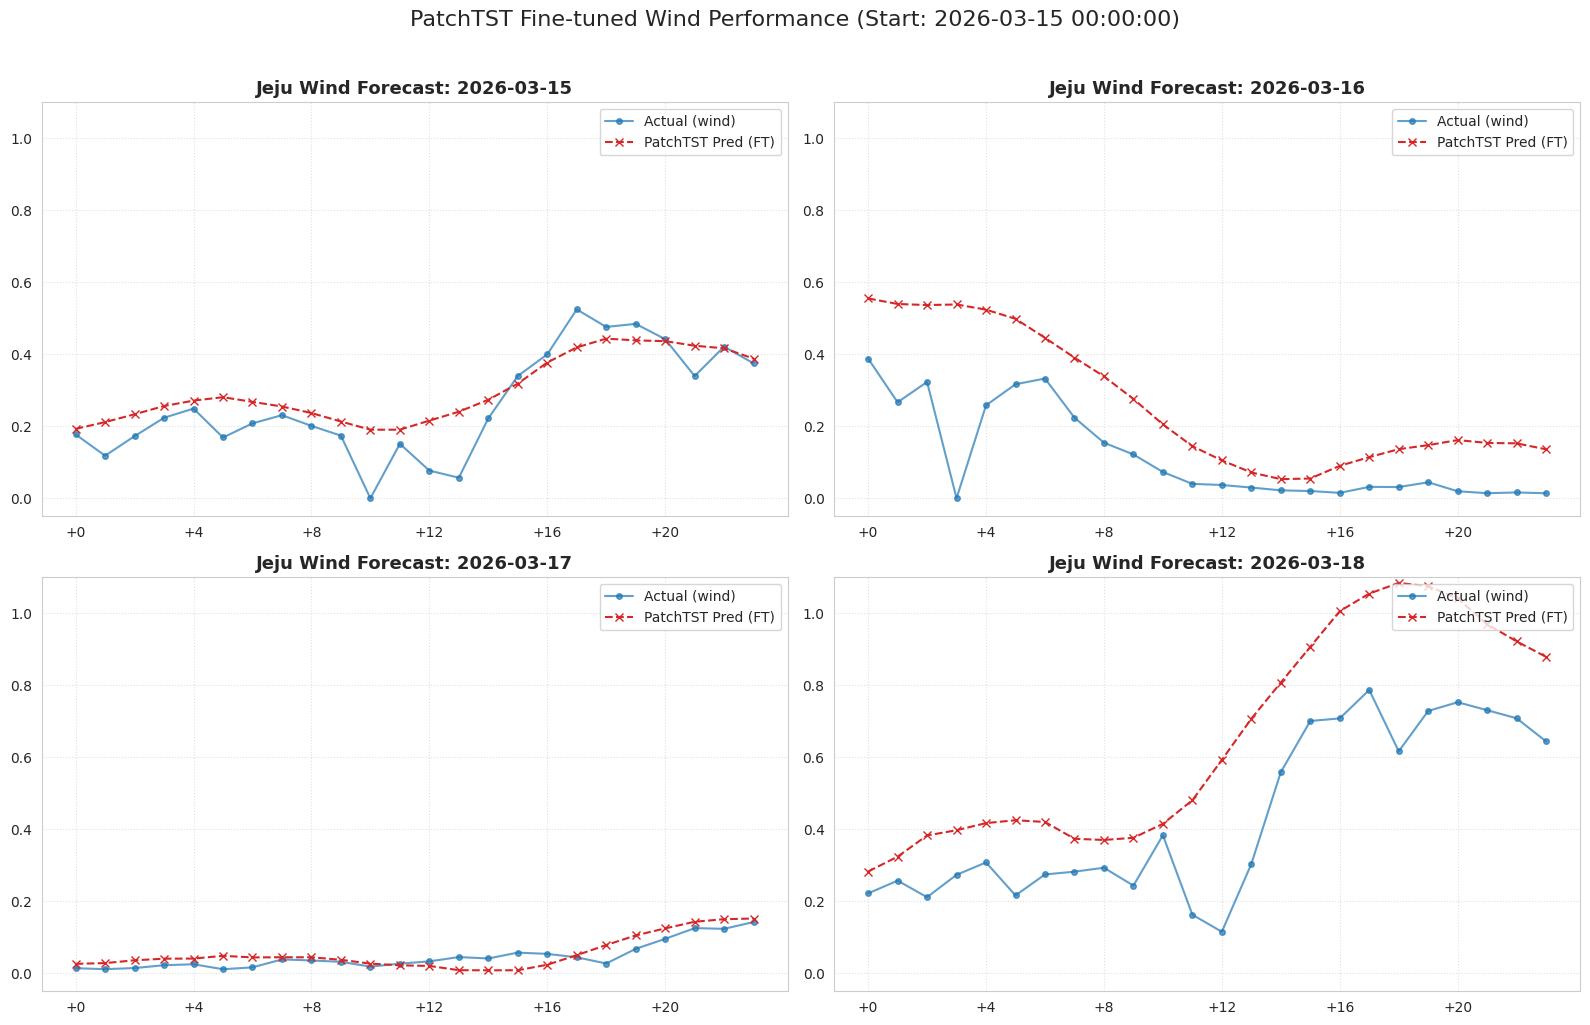

In [ ]:
# ==========================================
# Fine-tuned Wind 모델 평가
# ==========================================

best_model = PatchTST_Weather_Model(
    num_features=input_size_wind,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)

#weights_path = '/content/models/best_patchtst_wind_model_ft.pth'
weights_path = 'models/best_patchtst_wind_model_ft.pth'
best_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
best_model.eval()
print(f"✅ {weights_path} 로드 완료!")

# Test Dataset (26년 1월~ 데이터)
test_df_wind = df.loc['2026-01-01':].copy()
test_df_wind[future_features_wind] = scaler_wind.transform(test_df_wind[future_features_wind])

test_ds_wind = PatchTSTDataset(
    test_df_wind[features_wind].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx_wind,
    target_idx_wind
)
print(f"✅ Test Dataset: {len(test_ds_wind)}개 샘플 (기간: {test_df_wind.index[0]} ~ {test_df_wind.index[-1]})")

# ==========================================
# 시각화 함수
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

def plot_patchtst_forecast(start_date_str):
    try:
        target_start_loc = test_df_wind.index.get_loc(start_date_str)
    except KeyError:
        print(f"❌ '{start_date_str}'는 테스트 데이터 기간에 없습니다.")
        print(f"   사용 가능 기간: {test_df_wind.index[SEQ_LEN]} ~ {test_df_wind.index[-PRED_LEN]}")
        return

    base_idx = target_start_loc - SEQ_LEN
    if base_idx < 0 or base_idx + 72 >= len(test_ds_wind):
        print("❌ 시퀀스 데이터가 부족하여 그래프를 그릴 수 없습니다.")
        return

    indices = [base_idx, base_idx + 24, base_idx + 48, base_idx + 72]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = test_ds_wind[idx]
            batch_sample = {k: v.unsqueeze(0).to(DEVICE) for k, v in sample.items()}
            pred_y = best_model(batch_sample)

            actual = sample['future_y'].numpy()
            predicted = pred_y.squeeze().cpu().numpy()

            current_date = test_df_wind.index[target_start_loc + (i * 24)].strftime('%Y-%m-%d')

            ax = axes[i]
            ax.plot(actual, label='Actual (wind)', marker='o', markersize=4, color='#1f77b4', alpha=0.7)
            ax.plot(predicted, label='PatchTST Pred (FT)', marker='x', linestyle='--', color='#d62728', linewidth=1.5)
            ax.set_title(f"Jeju Wind Forecast: {current_date}", fontsize=13, fontweight='bold')
            ax.set_ylim(-0.05, 1.1)
            ax.set_xticks(range(0, 24, 4))
            ax.set_xticklabels([f"+{h}" for h in range(0, 24, 4)])
            ax.legend(loc='upper right')
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"PatchTST Fine-tuned Wind Performance (Start: {start_date_str})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 실행
#plot_patchtst_forecast('2026-01-15 00:00:00')
#plot_patchtst_forecast('2026-02-15 00:00:00')
plot_patchtst_forecast('2026-03-15 00:00:00')

#plot_patchtst_forecast('2026-03-13 00:00:00')

In [ ]:
train_df_raw = df.loc['2020-01-01':'2024-09-30'].copy()
scaler_fresh = RobustScaler()
scaler_fresh.fit(train_df_raw[future_features_wind])

print("Fresh scaler center:", scaler_fresh.center_[:5])
print("Fresh scaler scale:", scaler_fresh.scale_[:5])
print(df.loc['2026-03-16 00:00:00'][['temp_c', 'wind_spd', 'humidity']])

# ft_val_df에서 3월 16일 구간 직접 추출
target_start = '2026-03-02 00:00:00'  # 336시간 전
target_end = '2026-03-16 23:00:00'

sample_df = ft_val_df.loc[target_start:target_end]
print("sample length:", len(sample_df))

past_numeric = torch.FloatTensor(sample_df.iloc[:336][future_features_wind].values).unsqueeze(0)
past_y = torch.FloatTensor(sample_df.iloc[:336][['Wind_Utilization']].values).unsqueeze(0)
future_numeric = torch.FloatTensor(sample_df.iloc[336:360][future_features_wind].values).unsqueeze(0)

print("=== Colab 3/16 Debug ===")
print("past_numeric mean:", past_numeric.mean().item())
print("past_numeric std:", past_numeric.std().item())
print("past_y mean:", past_y.mean().item())
print("future_numeric mean:", future_numeric.mean().item())
print("past_numeric[0,0,:5]:", past_numeric[0, 0, :5].tolist())
print("future_numeric[0,0,:5]:", future_numeric[0, 0, :5].tolist())
# Colab
print("Colab features:", future_features_wind)
print("Colab scaler center:", scaler_wind.center_[:5])
print("Colab scaler scale:", scaler_wind.scale_[:5])

Fresh scaler center: [5.5   2.56  4.096 0.342 0.342]
Fresh scaler scale: [ 4.4     4.29   11.167   1.108   1.5825]
temp_c       8.4
wind_spd    10.3
humidity    63.0
Name: 2026-03-16 00:00:00, dtype: float64
sample length: 360
=== Colab 3/16 Debug ===
past_numeric mean: 0.4178633987903595
past_numeric std: 1.854905605316162
past_y mean: 0.3109070360660553
future_numeric mean: 0.03748146817088127
past_numeric[0,0,:5]: [-0.5227272510528564, 4.1235432624816895, 7.79340934753418, 0.3826714754104614, 0.1900789886713028]
future_numeric[0,0,:5]: [1.0909091234207153, -0.07226107269525528, -0.06456523388624191, -0.8888086676597595, 0.2679304778575897]
Colab features: ['wind_spd', 'wind_spd_sq', 'wind_spd_cu', 'wd_sin', 'wd_cos', 'Hour_sin', 'Hour_cos', 'Year_sin', 'Year_cos']
Colab scaler center: [5.5   2.56  4.096 0.342 0.342]
Colab scaler scale: [ 4.4     4.29   11.167   1.108   1.5825]


In [ ]:
torch.save(model_wind.state_dict(), 'models/best_patchtst_wind_model_ft.pth')

In [ ]:
df['wind_spd'].tail(10)

,wind_spd
timestamp,
2026-03-18 14:00:00,2.4
2026-03-18 15:00:00,2.1
2026-03-18 16:00:00,2.9
2026-03-18 17:00:00,1.0
2026-03-18 18:00:00,0.9
2026-03-18 19:00:00,1.7
2026-03-18 20:00:00,0.7
2026-03-18 21:00:00,1.0
2026-03-18 22:00:00,1.4


In [ ]:
joblib.dump(scaler_wind, 'robust_scaler_wind_claude2.pkl')

['robust_scaler_wind_claude2.pkl']

/tmp/ipykernel_1487/315274760.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


✅ /content/best_patchtst_wind_model_claude_mae.pth 로드 완료!


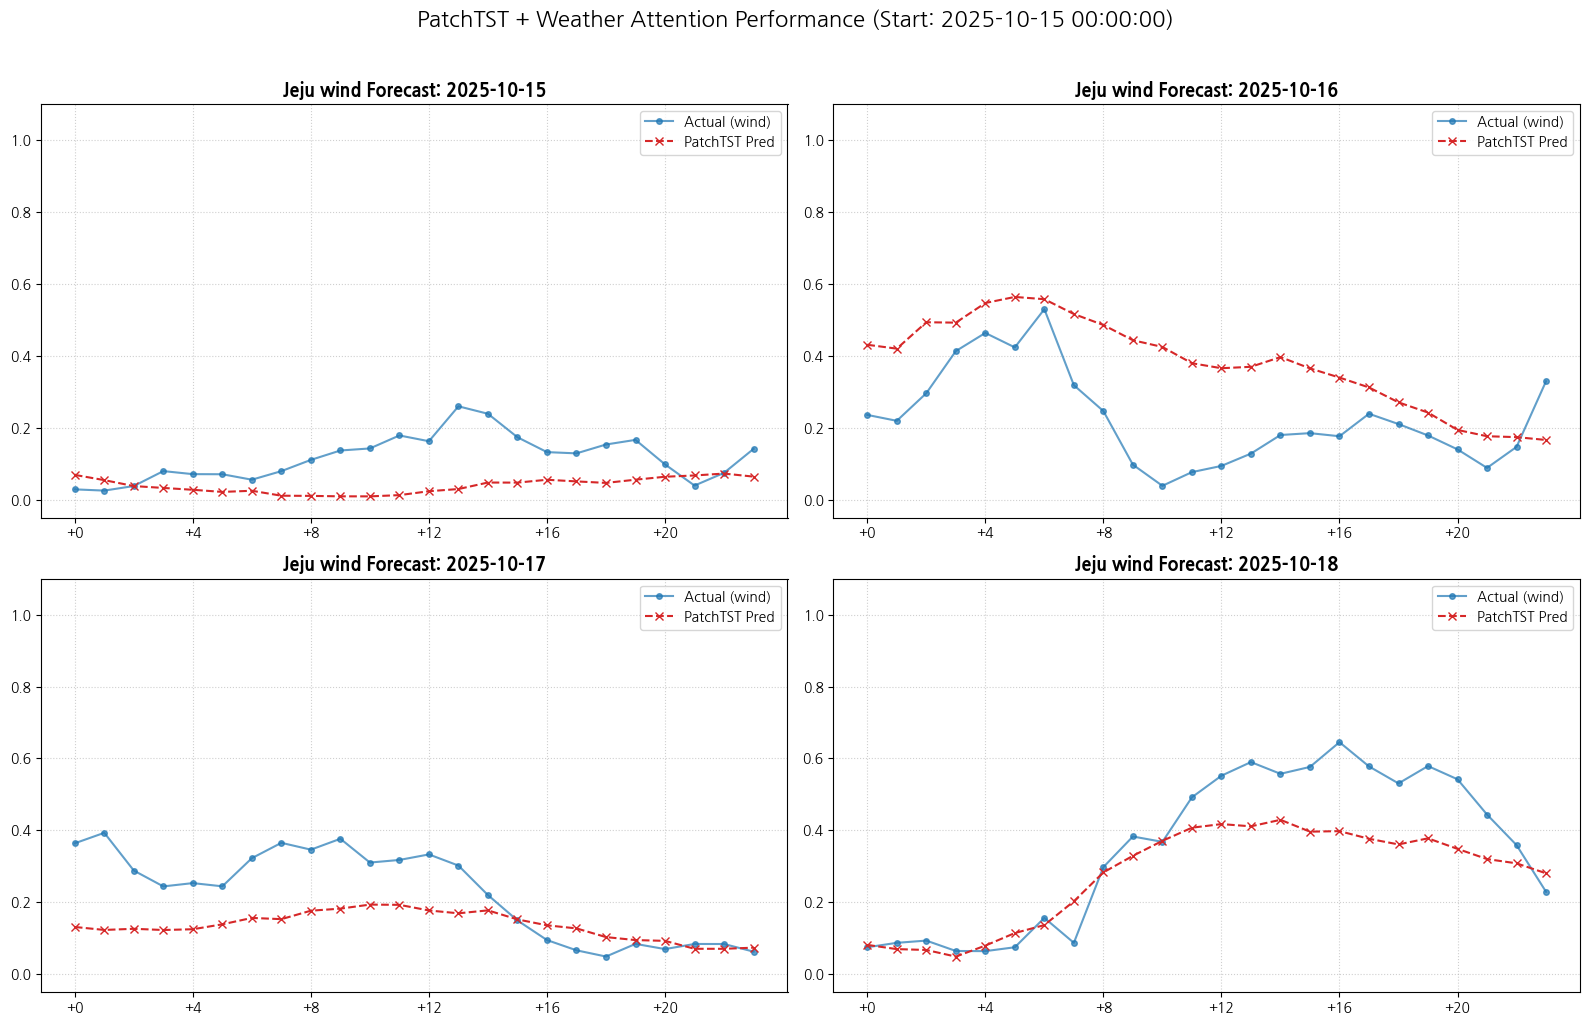

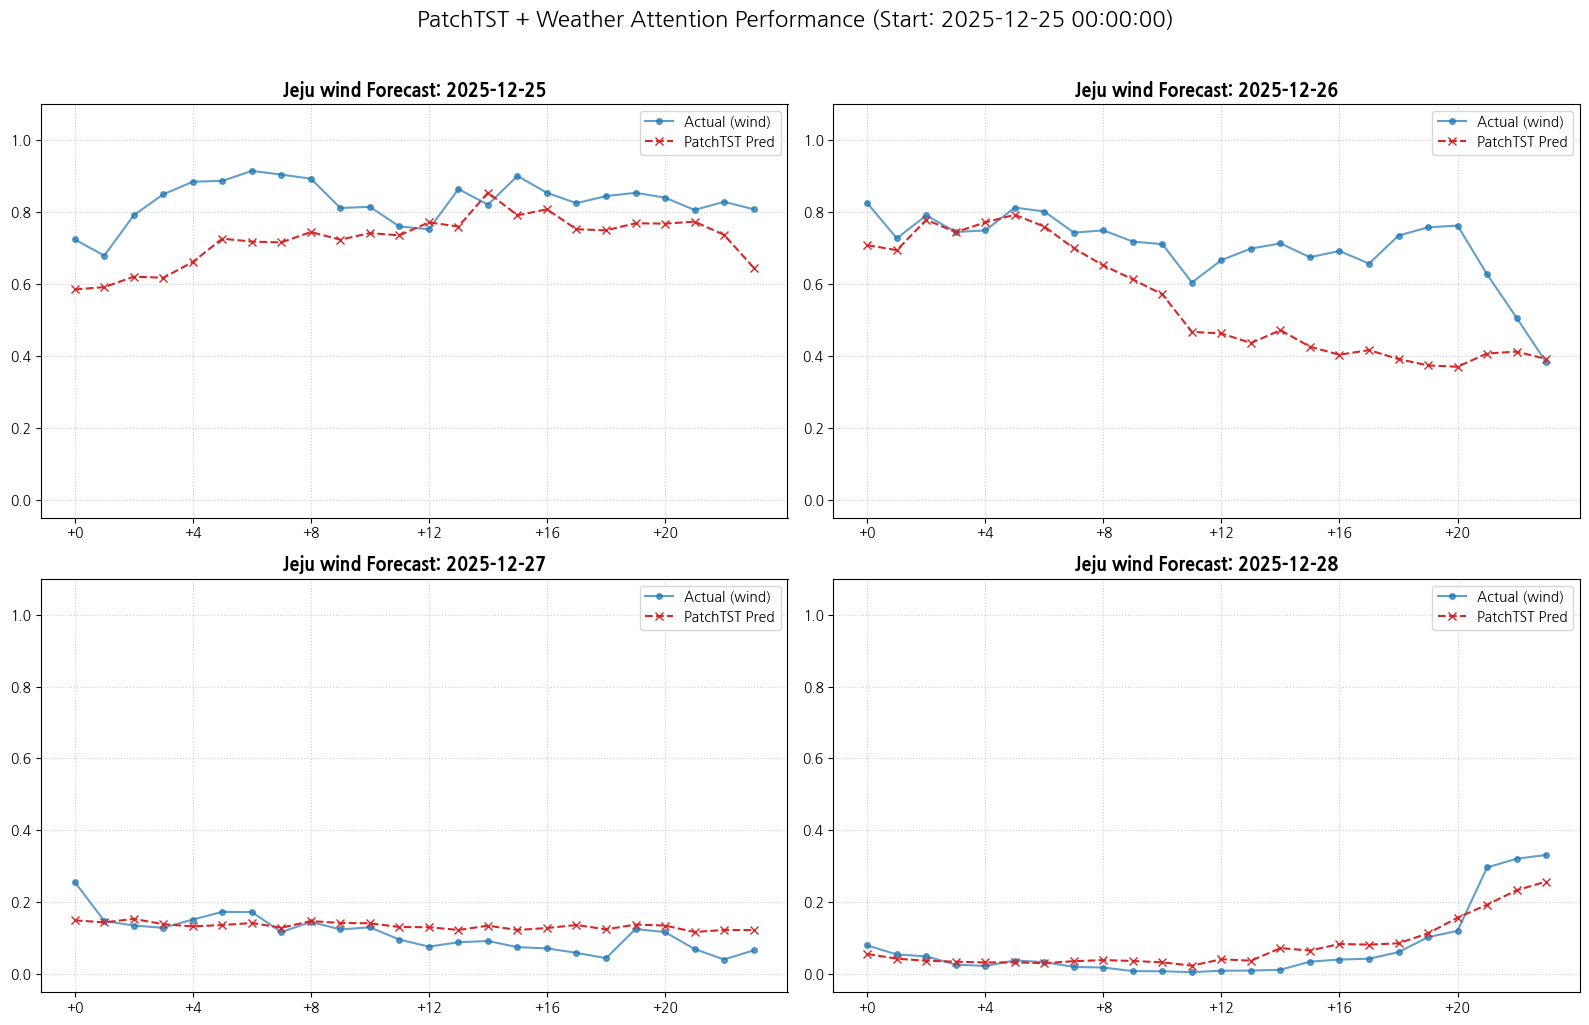

In [ ]:
# 1. 모델 인스턴스 생성 (15개 기상피처 + 1개 타겟 = 16)
#input_size = len(future_features) + 1
#best_model = PatchTST_Weather_Model(num_features=input_size_wind).to(DEVICE)
best_model = PatchTST_Weather_Model(
    num_features=input_size_wind,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)
#best_model = PatchTST_Weather_Model(num_features=input_size).to(DEVICE)
# 2. 저장된 가중치 불러오기 (파일명은 본인이 저장한 이름으로 수정)
# 에러 방지를 위해 map_location 설정을 추가했습니다.
weights_path = '/content/best_patchtst_wind_model_claude_mae.pth'
#weights_path = '/content/best_patchtst_wind_model_mse_12.pth'
#weights_path = '/content/best_patchtst_wind_model_mae.pth'
best_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
best_model.eval()

test_ds_wind = PatchTSTDataset(
    test_df_wind[features_wind].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx_wind,  # Wind용 future covariate 인덱스
    target_idx_wind        # Wind_Utilization 인덱스
)

print(f"✅ {weights_path} 로드 완료!")

import matplotlib.pyplot as plt
import numpy as np

def plot_patchtst_forecast(start_date_str):
    try:
        # 테스트 데이터에서 시작 위치 찾기
        target_start_loc = test_df_wind.index.get_loc(start_date_str)
    except KeyError:
        print(f"❌ 오류: '{start_date_str}'는 테스트 데이터 기간에 없습니다.")
        return

    # test_dataset은 PatchTSTDataset의 인스턴스여야 합니다.
    # !!! FIX: Changed 'test_ds' to 'test_ds_wind' !!!
    base_idx = target_start_loc - SEQ_LEN
    if base_idx < 0 or base_idx + 72 >= len(test_ds_wind):
        print("❌ 오류: 시퀀스 데이터가 부족하여 그래프를 그릴 수 없습니다.")
        return

    indices = [base_idx, base_idx + 24, base_idx + 48, base_idx + 72]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Dataset에서 샘플 가져오기 (딕셔너리 형태)
            # !!! FIX: Changed 'test_ds' to 'test_ds_wind' !!!
            sample = test_ds_wind[idx]

            # 모든 텐서에 배치 차원(1) 추가 및 장치 이동
            # v.unsqueeze(0) -> (Batch=1, Seq, Feat)
            batch_sample = {k: v.unsqueeze(0).to(DEVICE) for k, v in sample.items()}

            # 모델 추론
            # PatchTST 모델은 내부에서 batch를 통째로 받아 처리합니다.
            pred_y = best_model(batch_sample) # (1, 24)

            # 데이터 변환 (Numpy)
            actual = sample['future_y'].numpy()            # (24,)
            predicted = pred_y.squeeze().cpu().numpy()     # (24,)

            # 그래프 그리기
            # 실제 예측 대상 날짜 계산
            current_date = test_df_wind.index[target_start_loc + (i * 24)].strftime('%Y-%m-%d')

            ax = axes[i]
            ax.plot(actual, label='Actual (wind)', marker='o', markersize=4, color='#1f77b4', alpha=0.7)
            ax.plot(predicted, label='PatchTST Pred', marker='x', linestyle='--', color='#d62728', linewidth=1.5)

            ax.set_title(f"Jeju wind Forecast: {current_date}", fontsize=13, fontweight='bold')
            ax.set_ylim(-0.05, 1.1) # 0~1 범위를 약간 넘는지 확인하기 위해 1.1까지 설정
            ax.set_xticks(range(0, 24, 4))
            ax.set_xticklabels([f"+{h}" for h in range(0, 24, 4)])
            ax.legend(loc='upper right')
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"PatchTST + Weather Attention Performance (Start: {start_date_str})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 실행 예시
plot_patchtst_forecast('2025-10-15 00:00:00')
plot_patchtst_forecast('2025-12-25 00:00:00')